# Toxicity All Subset Exploration

This notebook profiles a random subset of `toxicity_all.csv` so we can understand the schema, the major sources of variation, and the most useful filtering decisions before training a model.


# Setup

Import the lightweight utilities we need for exploration and point the notebook to the merged toxicity dataset.


In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import numpy as np
import pandas as pd

from src.data.io import load_data
from src.data.cleaning import print_mol_types
from src.visualization.data_plots import plot_log_concentration_by_unit, plot_missing_fraction, plot_top_categories, plot_fractions

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

DATA_PATH = PROJECT_ROOT / "Data" / "toxicity_all.csv"

print("Setup complete")
print(f"Data file: {DATA_PATH}")


Setup complete
Data file: /home/vollmers/gnn-thesis/Data/toxicity_all.csv


## Load A Random Subset of Data


In [4]:
analysis_columns = [
    "SK_unique_id",
    "data_source",
    "species_group",
    "species_group_corrected",
    "species_common_name",
    "species_latin_name",
    "chemical_name",
    "conc_unit",
    "conc",
    "conc_sign",
    "duration_unit",
    "duration",
    "effect",
    "endpoint",
    "administration_route",
    "organism_lifestage",
    "organism_habitat",
    "SMILES",
    "organism_lifestage_categorized",
    "administration_route_categorized",
    "NCBI_rank_class",
    "NCBI_rank_order",
    "NCBI_rank_family",
    "NCBI_rank_genus",
    "NCBI_rank_species",
]

random_state = 11
subset_size = 50000
subset_size = None

df_all = load_data(DATA_PATH, analysis_columns)

subset_size = len(df_all) if subset_size is None else subset_size
subset_df = df_all.sample(n=subset_size, random_state=random_state).reset_index(drop=True)


print(f"Rows in full selected dataset: {len(df_all):,}")
print(f"Rows in subset: {len(subset_df):,}")
print(f"Columns included: {len(subset_df.columns)}")
print()
print("Subset preview")
print(subset_df.head())
print()
print("Column names")
print(subset_df.columns.tolist())


Rows in full selected dataset: 561,100
Rows in subset: 561,100
Columns included: 25

Subset preview
   SK_unique_id                              data_source  \
0       CAR6916           Carcinogenicity_cleaned_v1.txt   
1   AQTER923326  2025-06-24_Merged_REACH_ECOTOX_EFSA.txt   
2    RTECS82898                             RTECS_v3.csv   
3  AQTER1257071  2025-06-24_Merged_REACH_ECOTOX_EFSA.txt   
4   AQTER542929  2025-06-24_Merged_REACH_ECOTOX_EFSA.txt   

                   species_group species_group_corrected species_common_name  \
0                        rodents                 rodents                 rat   
1  flowers, trees, shrubs, ferns                  plants         Bread Wheat   
2                        rodents                 rodents               mouse   
3                           fish                    fish               Perch   
4                           fish                    fish      Fathead Minnow   

    species_latin_name  \
0    Rattus norvegicus   
1    t

# Missing and Fractions

## Layout And Missingness

Before filtering anything, check which columns are dense, which ones are sparse, and how much information is available for core modeling fields.


                                    dtype  non_null  missing_frac  n_unique
organism_lifestage_categorized     object    162080         0.711         3
organism_lifestage                 object    198594         0.646       128
administration_route_categorized   object    366090         0.348        22
organism_habitat                   object    371731         0.337         3
duration                          float64    428680         0.236      2309
duration_unit                      object    429343         0.235        60
administration_route               object    495431         0.117       329
chemical_name                      object    510853         0.090     86684
NCBI_rank_species                 float64    516089         0.080      6772
NCBI_rank_genus                   float64    539816         0.038      4550
NCBI_rank_class                   float64    549277         0.021       149
species_group                      object    557187         0.007        16
species_lati

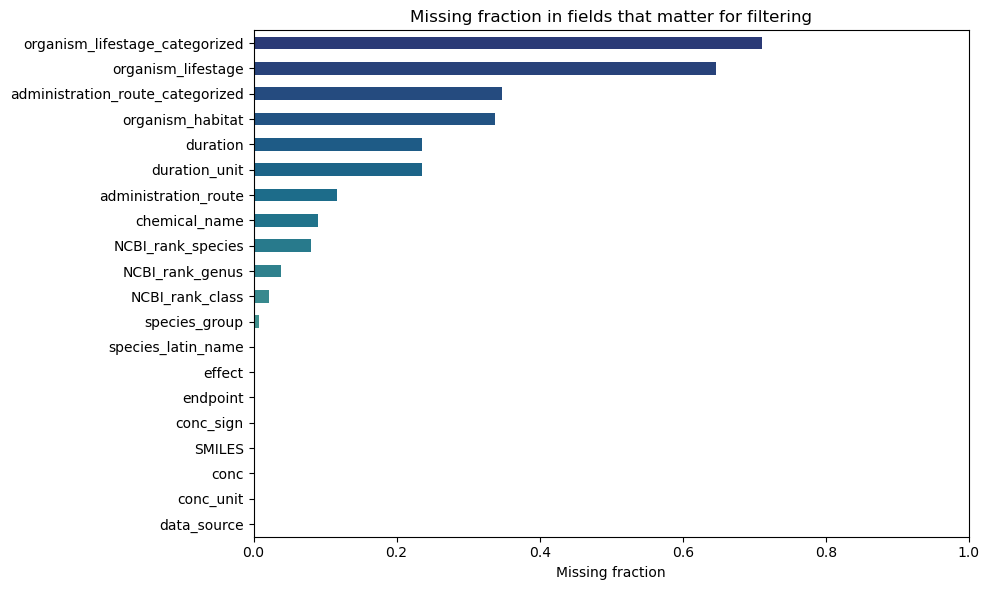

In [5]:
summary_columns = [
    "data_source",
    "species_group",
    "species_latin_name",
    "chemical_name",
    "SMILES",
    "conc",
    "conc_unit",
    "conc_sign",
    "duration",
    "duration_unit",
    "effect",
    "endpoint",
    "administration_route",
    "organism_lifestage",
    "organism_habitat",
    "organism_lifestage_categorized",
    "administration_route_categorized",
    "NCBI_rank_class",
    "NCBI_rank_genus",
    "NCBI_rank_species",
]

column_summary = pd.DataFrame({
    "dtype": subset_df[summary_columns].dtypes.astype(str),
    "non_null": subset_df[summary_columns].notna().sum(),
    "missing_frac": subset_df[summary_columns].isna().mean().round(3),
    "n_unique": subset_df[summary_columns].nunique(dropna=True),
}).sort_values(["missing_frac", "n_unique"], ascending=[False, False])

print(column_summary.to_string())

plot_missing_fraction(
    subset_df,
    columns=summary_columns,
    title="Missing fraction in fields that matter for filtering",
    figsize=(10, 6),
)


## Endpoint and Effect Fractions

Start with the relative frequency of the response endpoints so it is obvious which assay readouts dominate the subset.


          fraction
endpoint          
EC50      0.559963
NOEC      0.244701
LOEC      0.168198
EC10      0.027138


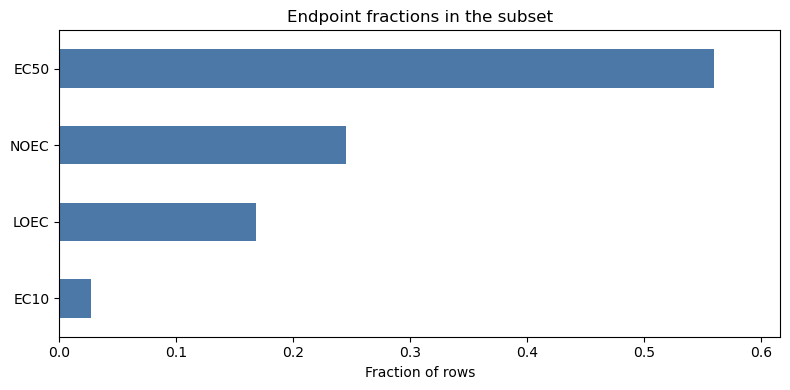

In [6]:
endpoint_fraction = plot_fractions(
    subset_df["endpoint"],
    "Endpoint fractions in the subset",
    color="#4c78a8",
    figsize=(8, 4),
)

print(endpoint_fraction.to_string())


        fraction
effect          
MOR     0.489980
POP     0.158065
GRO     0.095921
BEH     0.069314
REP     0.058508
ITX     0.032114
PHY     0.028052
DVP     0.027510
MPH     0.021814
INJ     0.012588
CAR     0.006134


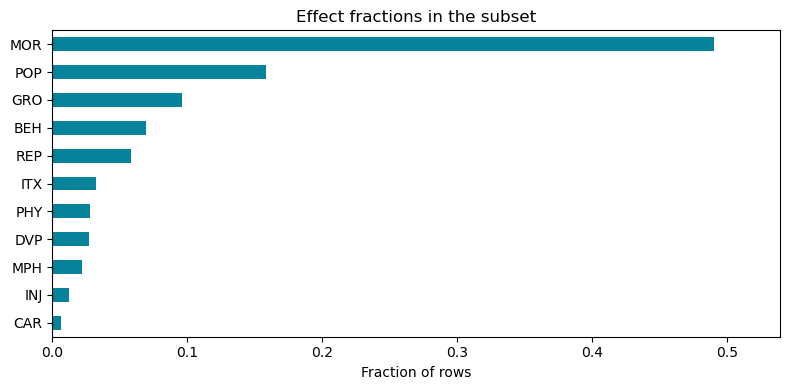

In [6]:
effect_fraction = plot_fractions(
    subset_df["effect"],
    "Effect fractions in the subset",
    color="#07829b",
    figsize=(8, 4),
)

print(effect_fraction.to_string())

## Concentration Unit Fractions

Next, inspect the relative frequency of concentration units because unit choice is likely to be an early filtering decision.


            fraction
conc_unit           
mg/L        0.460116
mg/kg       0.224735
kg/m2       0.124660
ppm         0.084122
mg/kg bw    0.030679
mg/kg bw/d  0.022035
%           0.017701
mg/kg soil  0.012429
mg/org      0.008412
mg/kg diet  0.006534
mg/L air    0.003138
mg/kg org   0.002208
mg/org/d    0.001852
mL/kg bw    0.001378


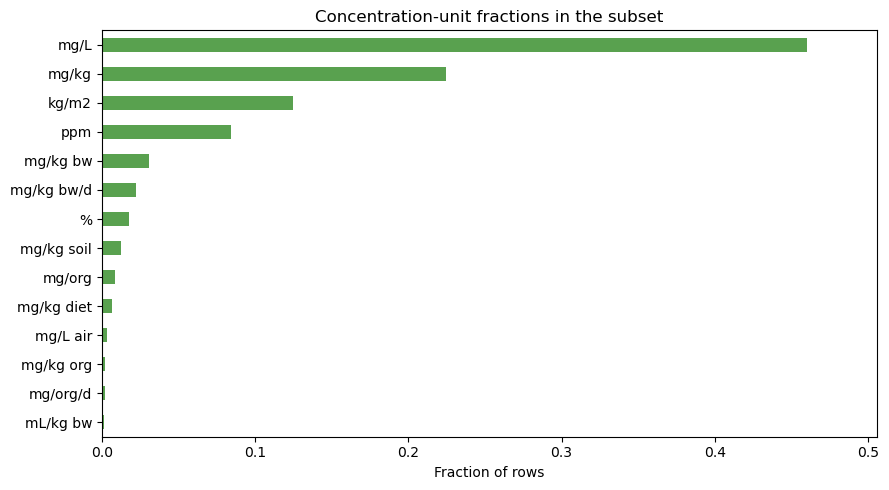

In [7]:
conc_unit_fraction = plot_fractions(
    subset_df["conc_unit"],
    "Concentration-unit fractions in the subset",
    top_n=15,
    figsize=(9, 5),
    color="#59a14f",
)

print(conc_unit_fraction.to_string())

## Duration Fractions

               fraction
duration_unit          
h              0.745436
Missing        0.234819
gs             0.005867
hpf            0.002552
dph            0.002021
ge             0.001969
dpf            0.001060
dpe            0.000882
dpp            0.000677
s              0.000588
hv             0.000556
brd            0.000556
stg            0.000380
go             0.000264
wpe            0.000262
dpgm           0.000257
ins            0.000217
dpn            0.000216
nf             0.000187
zgs            0.000132
dpel           0.000128
wph            0.000116
hph            0.000100
dphv           0.000068
hpe            0.000066
wpp            0.000055
el             0.000045
dpmm           0.000045
dd             0.000039
dpu            0.000034
wkpm           0.000032
crs            0.000032
ls             0.000030
tls            0.000029
mpf            0.000027
cs             0.000023
blm            0.000021
cd             0.000021
lsi            0.000020
dpfl           0

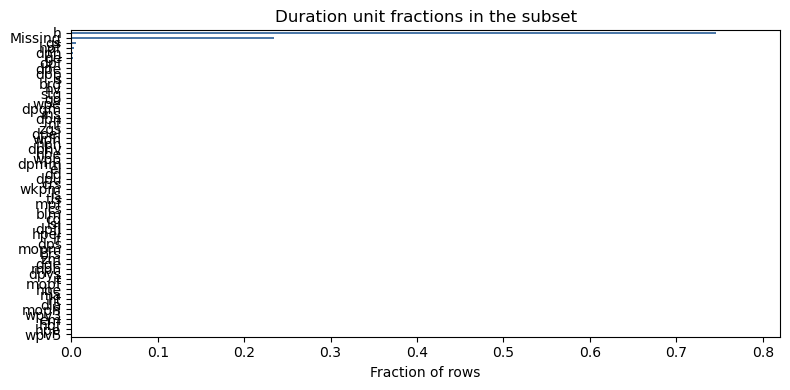

In [8]:
duration_fraction = plot_fractions(
    subset_df["duration_unit"],
    "Duration unit fractions in the subset",
    color="#4c78a8",
    figsize=(8, 4),
)

print(duration_fraction.to_string())

In [ ]:
unit_stats = (
    subset_df.groupby("duration_unit")["duration"]
    .agg(
        n_records="size",
        min_value="min",
        median_value="median",
        p95_value=lambda s: s.quantile(0.95),
        max_value="max",
    )
    .sort_values("n_records", ascending=False)
    .head(12)
    .round(4)
)
print("Duration scale summary by unit")
print(unit_stats.to_string())



Duration scale summary by unit
               n_records  min_value  median_value  p95_value  max_value
duration_unit                                                          
h                 418264      0.004          96.0     3024.0   518400.0
gs                  3292      1.000           1.0        3.0      133.0
hpf                 1432      2.000          96.0      144.0     3652.5
dph                 1134      1.000          30.0      180.0      420.0
ge                  1105      1.000           2.0        6.0       22.0
dpf                  595      1.000          10.0      120.0      180.0
dpe                  495      1.000          17.0       90.0      102.0
dpp                  380      7.000          54.0      120.0      170.0
s                    330      0.500          20.5      600.0     1619.0
hv                   312      0.500           1.0        5.0      127.0
brd                  312      1.000           3.0        6.0       10.0
stg                  213      0.1

## Administration Route Fractions

Administration route is much sparser and more fragmented, so a fraction view helps show how concentrated the common routes really are.


In [1]:
route_fraction = plot_fractions(
    subset_df["administration_route_categorized"],
    "Top administration-route fractions in the subset",
    top_n=15,
    figsize=(10, 6),
    color="#e15759",
)

print(route_fraction.to_string())

all_routes = subset_df["administration_route"].fillna("Missing").astype(str).value_counts(normalize=True)
print()
print(f"Unique administration routes: {all_routes.shape[0]}")
print(f"Fraction outside top 15 routes: {1 - route_fraction['fraction'].sum():.3f}")


NameError: name 'plot_fractions' is not defined

## Concentration Scales And Common Combinations

After the basic fractions, inspect the numeric spread within each concentration unit and the most common endpoint-unit combinations.


In [14]:
unit_stats = (
    subset_df.groupby("conc_unit")["conc"]
    .agg(
        n_records="size",
        min_value="min",
        median_value="median",
        p95_value=lambda s: s.quantile(0.95),
        max_value="max",
    )
    .sort_values("n_records", ascending=False)
    .head(12)
    .round(4)
)

print("Concentration scale summary by unit")
print(unit_stats.to_string())
print()
print("Most common endpoint x concentration-unit combinations")
print(
    subset_df.groupby(["endpoint", "conc_unit"])
    .size()
    .sort_values(ascending=False)
    .head(15)
    .to_string()
)
print()
print("Most common species-group x endpoint x unit combinations")
print(
    subset_df.groupby(["species_group", "endpoint", "conc_unit"])
    .size()
    .sort_values(ascending=False)
    .head(15)
    .to_string()
)

# plot_log_concentration_by_unit(subset_df, top_n=8, figsize=(11, 5))


Concentration scale summary by unit
            n_records  min_value  median_value  p95_value     max_value
conc_unit                                                              
mg/L           258171     0.0000        1.2800   919.2053  4.620000e+34
mg/kg          126099     0.0000      181.0000  3100.0000  1.040000e+06
kg/m2           69947     0.0000        0.0001     0.0050  9.054600e+00
ppm             47201     0.0000       11.3000  5000.0000  1.000000e+09
mg/kg bw        17214     0.0010      630.0000  8000.0000  2.838000e+32
mg/kg bw/d      12364     0.0000      100.0000  1600.0000  1.600000e+05
%                9932     0.0000        0.2000    20.0000  1.290000e+03
mg/kg soil       6974     0.0001       27.6500  3204.2000  1.423560e+05
mg/org           4720     0.0000        0.0005     0.7978  7.284300e+28
mg/kg diet       3666     0.0001       74.0000  5000.0000  2.270000e+06
mg/L air         1761     0.0000        1.7230    87.5000  2.357600e+04
mg/kg org        1239     0.

# Main Data

## Organism And Taxonomy Variety

Look at how broad the subset is across species groups, Latin names, and NCBI taxonomy ids.


Taxonomy info
                 column  unique_non_null  missing_frac
          species_group               16         0.007
species_group_corrected               20         0.000
     species_latin_name            10049         0.002
        NCBI_rank_class              149         0.021
        NCBI_rank_order              517         0.034
       NCBI_rank_family             1684         0.031
        NCBI_rank_genus             4550         0.038
      NCBI_rank_species             6772         0.080

Top species groups
species_group
rodents                          152075
fish                              93964
insects/spiders                   67286
flowers, trees, shrubs, ferns     66548
crustaceans                       63815
algae                             34348
worms                             15443
molluscs                          13228
invertebrates                     12261
fungi                             11587
birds                             11367
amphibians       

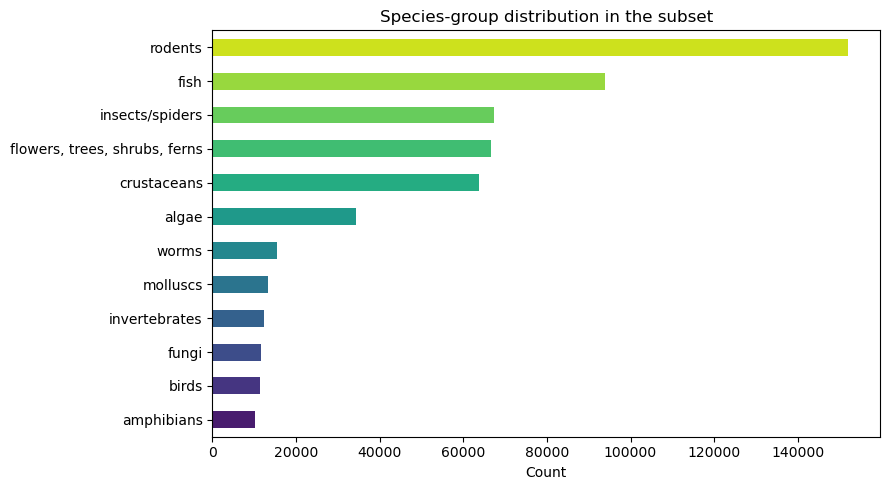

In [19]:
taxonomy_levels = [
    "species_group",
    "species_group_corrected",
    "species_latin_name",
    "NCBI_rank_class",
    "NCBI_rank_order",
    "NCBI_rank_family",
    "NCBI_rank_genus",
    "NCBI_rank_species",
]

taxonomy_summary = pd.DataFrame({
    "column": taxonomy_levels,
    "unique_non_null": [subset_df[col].nunique(dropna=True) for col in taxonomy_levels],
    "missing_frac": [subset_df[col].isna().mean().round(3) for col in taxonomy_levels],
})

print("Taxonomy info")
print(taxonomy_summary.to_string(index=False))
print()
print("Top species groups")
print(subset_df["species_group"].fillna("Missing").value_counts().head(12).to_string())
print()
# print("Top Latin names")
# print(subset_df["species_latin_name"].fillna("Missing").value_counts().head(12).to_string())
# print()
# print("Top NCBI class ids")
# print(subset_df["NCBI_rank_class"].fillna("Missing").value_counts().head(12).to_string())
# print()
# print("Top NCBI species ids")
# print(subset_df["NCBI_rank_species"].fillna("Missing").value_counts().head(12).to_string())

plot_top_categories(subset_df["species_group"], "Species-group distribution in the subset", top_n=12, figsize=(9, 5))


## Molecule Variety

Check how many unique molecules appear in the subset, how often they repeat, and whether there are salts, lone atoms, or metals to think about.


In [20]:
smiles_counts = subset_df["SMILES"].dropna().value_counts()
unique_smiles = subset_df["SMILES"].nunique(dropna=True)
unique_chemical_names = subset_df["chemical_name"].nunique(dropna=True)


print(f"Rows in subset: {len(subset_df):,}")
print(f"Unique SMILES: {unique_smiles:,}")
print(f"Unique chemical names: {unique_chemical_names:,}")
print(f"Duplicate rows by SMILES: {len(subset_df) - unique_smiles:,}")
print(f"Median records per SMILES: {smiles_counts.median():.1f}")
print(f"95th percentile records per SMILES: {smiles_counts.quantile(0.95):.1f}")
print(f"Max records for a single SMILES: {smiles_counts.max():.0f}")
print()
print_mol_types(subset_df.dropna(subset=["SMILES"]))
print()

top_molecules = (
    subset_df.groupby(["SMILES", "chemical_name"], dropna=False)
    .size()
    .sort_values(ascending=False)
    .head(12)
    .reset_index(name="n_records")
)
top_molecules["SMILES_short"] = top_molecules["SMILES"].fillna("Missing").str.slice(0, 70)

print("Most repeated molecules in the subset")
print(top_molecules[["n_records", "chemical_name", "SMILES_short"]].to_string(index=False))


Rows in subset: 561,100
Unique SMILES: 82,041
Unique chemical names: 86,684
Duplicate rows by SMILES: 479,059
Median records per SMILES: 1.0
95th percentile records per SMILES: 11.0
Max records for a single SMILES: 10365



[09:05:52] WARNING: not removing hydrogen atom without neighbors
[09:05:52] WARNING: not removing hydrogen atom without neighbors
[09:05:52] WARNING: not removing hydrogen atom without neighbors
[09:05:52] WARNING: not removing hydrogen atom without neighbors
[09:05:53] WARNING: not removing hydrogen atom without neighbors
[09:05:53] WARNING: not removing hydrogen atom without neighbors
[09:05:53] WARNING: not removing hydrogen atom without neighbors
[09:05:53] WARNING: not removing hydrogen atom without neighbors
[09:05:53] WARNING: not removing hydrogen atom without neighbors
[09:05:53] WARNING: not removing hydrogen atom without neighbors
[09:05:53] WARNING: not removing hydrogen atom without neighbors
[09:05:53] WARNING: not removing hydrogen atom without neighbors
[09:05:53] WARNING: not removing hydrogen atom without neighbors
[09:05:53] WARNING: not removing hydrogen atom without neighbors
[09:05:53] WARNING: not removing hydrogen atom without neighbors
[09:05:53] WARNING: not r

Total molecules: 561100
Unique molecules: 82041
Salts: 135099, 24.08%
Single atoms: 1474, 0.26%
Metals: 103825, 18.50%

Most repeated molecules in the subset
 n_records                                                                                                                              chemical_name                                              SMILES_short
      9807                                                                                                        Sulfuric acid copper(2+) salt (1:1)                                  O=S(=O)([O-])[O-].[Cu+2]
      6830                                                                    Phosphorothioic acid, O,O-Diethyl O-(3,5,6-trichloro-2-pyridinyl) ester                          CCOP(=S)(OCC)Oc1nc(Cl)c(Cl)cc1Cl
      6174                                                                             6-Chloro-N-ethyl-N'-(1-methylethyl)-1,3,5-triazine-2,4-diamine                                   CCNc1nc(Cl)nc(NC(C)C)n1
      5097

# Other

## Additional Experimental Descriptors

Keep the remaining experimental context here so the earlier sections can stay focused on endpoint, unit, route, and scale decisions.


Top data sources
data_source
2025-06-24_Merged_REACH_ECOTOX_EFSA.txt    421978
RTECS_v3.csv                               117719
Acute_Toxicity_cleaned_v1.txt               13846
Reproductive_toxicity_cleaned_v1.txt         5583
Carcinogenicity_cleaned_v1.txt               1974

Top effects
effect
MOR    274928
POP     88690
GRO     53821
BEH     38892
REP     32829
ITX     18019
PHY     15740
DVP     15436
MPH     12240
INJ      7063
CAR      3442

Top duration units
duration_unit
h          418264
Missing    131757
gs           3292
hpf          1432
dph          1134
ge           1105
dpf           595
dpe           495
dpp           380
s             330
hv            312
brd           312
stg           213
go            148
wpe           147

Concentration sign values
conc_sign
=    561100


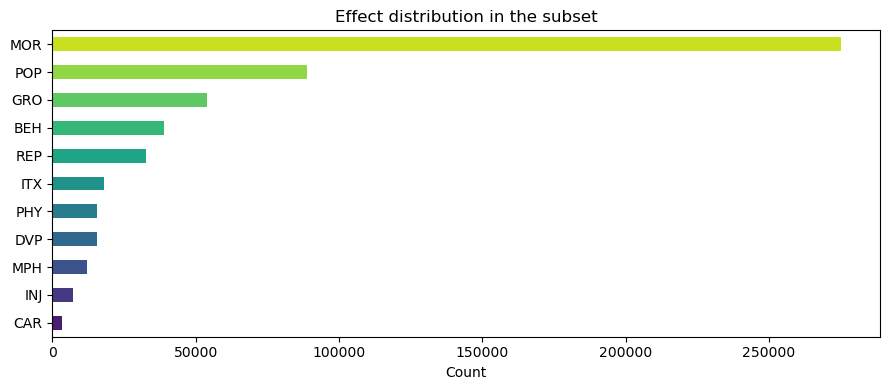

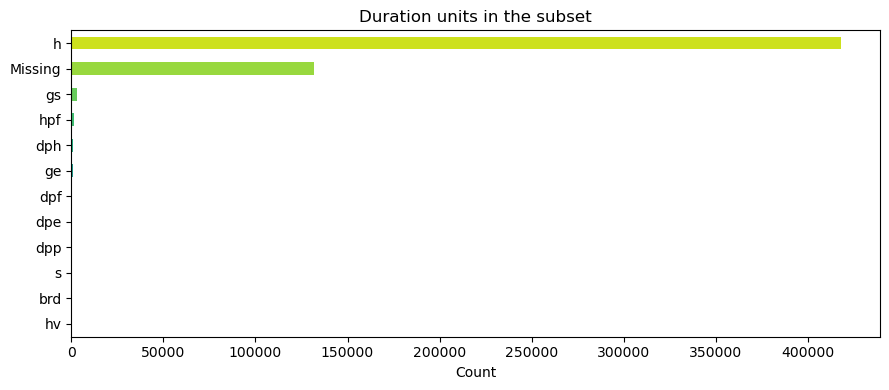

In [21]:
print("Top data sources")
print(subset_df["data_source"].fillna("Missing").value_counts().head(12).to_string())
print()
print("Top effects")
print(subset_df["effect"].fillna("Missing").value_counts().head(12).to_string())
print()
print("Top duration units")
print(subset_df["duration_unit"].fillna("Missing").value_counts().head(15).to_string())
print()
print("Concentration sign values")
print(subset_df["conc_sign"].fillna("Missing").value_counts().to_string())

# plot_top_categories(subset_df["data_source"], "Data-source distribution in the subset", top_n=12, figsize=(9, 4))
plot_top_categories(subset_df["effect"], "Effect distribution in the subset", top_n=12, figsize=(9, 4))
plot_top_categories(subset_df["duration_unit"], "Duration units in the subset", top_n=12, figsize=(9, 4))


## Filtering Clues For Modeling

Use the subset to estimate which kinds of filters are realistic before moving on to feature engineering or model training.


In [22]:
core_model_fields = ["SMILES", "conc", "conc_unit", "endpoint", "effect", "NCBI_rank_species"]

filter_readiness = pd.Series({
    "Rows with all core model fields": subset_df[core_model_fields].notna().all(axis=1).sum(),
    "Rows with duration and unit present": subset_df[["duration", "duration_unit"]].notna().all(axis=1).sum(),
    "Rows with administration route present": subset_df["administration_route"].notna().sum(),
    "Rows with categorized route present": subset_df["administration_route_categorized"].notna().sum(),
    "Rows with categorized lifestage present": subset_df["organism_lifestage_categorized"].notna().sum(),
})

is_aquatic_group = subset_df["species_group"].isin(["fish", "crustaceans", "algae", "amphibians", "molluscs", "worms", "invertebrates"])
is_mammalian_group = subset_df["species_group"].isin(["rodents", "mammals", "primates", "birds"])
mgkg_like = subset_df["conc_unit"].astype(str).str.contains("mg/kg", na=False)

candidate_filters = pd.DataFrame([
    {
        "candidate_subset": "Aquatic acute-like (mg/L + EC50)",
        "rows_in_subset": ((subset_df["conc_unit"] == "mg/L") & (subset_df["endpoint"] == "EC50") & is_aquatic_group).sum(),
    },
    {
        "candidate_subset": "Aquatic chronic-like (mg/L + NOEC/LOEC/EC10)",
        "rows_in_subset": ((subset_df["conc_unit"] == "mg/L") & subset_df["endpoint"].isin(["NOEC", "LOEC", "EC10"]) & is_aquatic_group).sum(),
    },
    {
        "candidate_subset": "Mammalian acute-like (mg/kg family + EC50)",
        "rows_in_subset": (mgkg_like & (subset_df["endpoint"] == "EC50") & is_mammalian_group).sum(),
    },
    {
        "candidate_subset": "Rows with duration available",
        "rows_in_subset": subset_df[["duration", "duration_unit"]].notna().all(axis=1).sum(),
    },
])

print(filter_readiness.to_string())
print()
print("Candidate subsets to inspect next")
print(candidate_filters.to_string(index=False))


Rows with all core model fields            516089
Rows with duration and unit present        428680
Rows with administration route present     495431
Rows with categorized route present        366090
Rows with categorized lifestage present    162080

Candidate subsets to inspect next
                            candidate_subset  rows_in_subset
            Aquatic acute-like (mg/L + EC50)          124453
Aquatic chronic-like (mg/L + NOEC/LOEC/EC10)           79067
  Mammalian acute-like (mg/kg family + EC50)          126599
                Rows with duration available          428680


## What Stands Out From This Sample

- The file mixes very different regimes, including aquatic ecotoxicology and mammalian acute toxicity.
- Units are not harmonized, so filtering by `conc_unit` is likely a first-step decision rather than something to postpone.
- Endpoints are dominated by `EC50`, but `NOEC`, `LOEC`, and `EC10` are also common enough to matter.
- Route, duration, and lifestage are much less complete than the core response columns, so requiring them will shrink the usable data.
- Taxonomy coverage is broad enough that filtering by species group or taxonomic rank should be feasible, but the exact choice will strongly affect class balance and unit consistency.
